In [9]:
from astropy import units as u
from astropy.table import Table
from astropy.constants import G, c, k_B, sigma_sb
import simple_disk as sd
from matplotlib import pyplot as plt
import disk_newton_solver as newton
import numpy as np
from disk_newton_solver import Tester
import pandas as pd
import seaborn as sns

In [10]:
Munit = 1e8 * u.Msun 
MdotUnit = 1e23 * u.kg/u.s 

M = 1e8 * u.Msun 
Mdot = 1e23 * u.kg/u.s

r = 3 * (G * M / c**2)  
alpha = 0.1
R_star = 2 * (G * M / c**2)
fMdot = Mdot * (1.0 - np.sqrt((R_star / r).decompose()))

2.09e8 * u.m * (alpha)**(-1/10) * (1)**(3/4) * (fMdot/Mdot)**(3/20) * (3)**(9/8)
1.59e12 * u.m * (alpha)**(0) * (1)**(0) * (fMdot/Mdot)**(1) * (3)**(0)

<Quantity 2.91770436e+11 m>

In [11]:
R_star.to(u.AU)

<Quantity 1.97412574 AU>

In [12]:
_.to(u.AU)

<Quantity 1.97412574 AU>

In [13]:
sd.h(alpha=0.1, M=M, fMdot=fMdot, r=r, zone=3, scale="AGN").to(u.AU)

<Quantity 0.00469385 AU>

In [14]:
def h1(r):
    global Munit, MdotUnit
    a = 0.1
    M = 1e8 * u.Msun
    Mdot = 1e23 * u.kg/u.s 
    fMdot = (Mdot) * (1.0 - np.sqrt((R_star / r)))
    
    Runit = G * M / c / c

    
    scale = 1.59e12 * u.m 
    return (scale * (alpha)**0 * (M/Munit)**0 * (fMdot / MdotUnit)**(1) * (r/Runit)**(0)).si

def h2(r):
    global Munit, MdotUnit
    a = 0.1
    M = 1e8 * u.Msun
    Mdot = 1e23 * u.kg/u.s 
    fMdot = (Mdot) * (1.0 - np.sqrt((R_star / r)))
    
    Runit = G * M / c / c

    
    scale = 4.45e8 * u.m 
    return (scale * (alpha)**(-1/10) * (M/Munit)**(7/10) * (fMdot / MdotUnit)**(1/5) * (r/Runit)**(21/20)).si

def h3(r):
    global Munit, MdotUnit
    a = 0.1
    M = 1e8 * u.Msun
    Mdot = 1e23 * u.kg/u.s 
    fMdot = (Mdot) * (1.0 - np.sqrt((R_star / r)))
    
    Runit = G * M / c / c

    
    scale = 2.09e8 * u.m 
    return (scale * (alpha)**(-1/10) * (M/Munit)**(3/4) * (fMdot / MdotUnit)**(3/20) * (r/Runit)**(9/8)).si

In [15]:
rvals = [r * u.AU for r in np.linspace(0,10000,100)]
y1 = [h1(r).to(u.AU).value for r in rvals]
y2 = [h2(r).to(u.AU).value for r in rvals]
y3 = [h3(r).to(u.AU).value for r in rvals]

x = [r.value for r in rvals]


Text(0, 0.5, 'Disk Half Thickness (AU)')

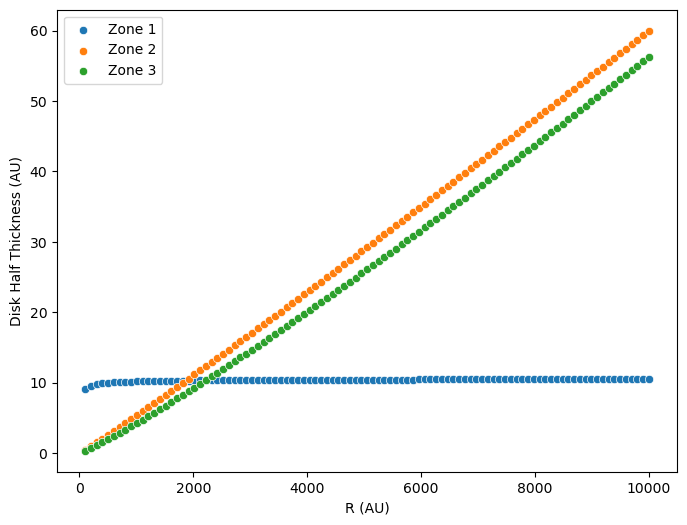

In [16]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(ax=ax, x=x, y=y1, label="Zone 1")
sns.scatterplot(ax=ax, x=x, y=y2, label="Zone 2")
sns.scatterplot(ax=ax, x=x, y=y3, label="Zone 3")
ax.set_xlabel("R (AU)")
ax.set_ylabel("Disk Half Thickness (AU)")